In [1]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -------------------------
# Model components
# -------------------------
class FourierFeatures(nn.Module):
    def __init__(self, in_features=1, out_features=64, scale=10.0, device=None, dtype=torch.float32):
        super().__init__()
        B = torch.randn((out_features, in_features), device=device, dtype=dtype) * scale
        self.register_buffer('B', B)
        self.register_buffer('two_pi', torch.tensor(2.0 * np.pi, device=device, dtype=dtype))

    def forward(self, x):
        x_proj = self.two_pi * (x @ self.B.T)
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)


class ResidualBlock(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.fc1 = nn.Linear(width, width)
        self.fc2 = nn.Linear(width, width)

    def forward(self, x):
        return x + self.fc2(torch.sin(self.fc1(x)))


class F_PINN(nn.Module):
    def __init__(self, N_fields, embed_dim=64, hidden=128, blocks=3, fourier_scale=10.0, device=None, dtype=torch.float32):
        super().__init__()
        self.N_fields = N_fields
        self.fourier = FourierFeatures(1, embed_dim, scale=fourier_scale, device=device, dtype=dtype)
        layers = [nn.Linear(2 * embed_dim, hidden)]
        for _ in range(blocks):
            layers.append(ResidualBlock(hidden))
        self.net = nn.Sequential(*layers)
        self.output = nn.Linear(hidden, 1 + N_fields)
        self.softplus = nn.Softplus()

    def forward(self, t):
        x = self.fourier(t)
        x = self.net(x)
        x = self.output(x)
        a = self.softplus(x[:, 0:1]).clamp(min=1e-6)
        phi = x[:, 1:]
        return a, phi

# -------------------------
# PINN solver
# -------------------------
class PINNSolver:
    def __init__(self, N_fields=1, m_vec=[200],
                 rho_m0=0.81, rho_r0=0.00027138, rho_l0=2.19,
                 a0=1e-4, phi0=None, phi_dot0=None,
                 t_span=(0.0, 5e-6), t_eval=None, folder_name='results',
                 device=None, dtype=torch.float32, a_eq = 2.9e-4):

        self.device = device or (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
        self.dtype = dtype
        print("Using device:", self.device)

        self.N_fields = int(N_fields)
        self.m_vec = np.array(m_vec if m_vec is not None else [70.0] * self.N_fields, dtype=np.float32)
        self.a_eq = a_eq
        self.rho_m0 = rho_m0*a_eq**3
        self.rho_r0 = rho_r0*a_eq**4
        self.rho_l0 = rho_l0

        self.a0 = float(a0)
        self.phi0 = np.array(phi0 if phi0 is not None else [0.04] * self.N_fields, dtype=np.float32)
        self.phi_dot0 = np.array(phi_dot0 if phi_dot0 is not None else [0.0] * self.N_fields, dtype=np.float32)
        self.y0 = np.concatenate([[self.a0], self.phi0, self.phi_dot0]).astype(np.float32)

        self.t_span = t_span
        if t_eval is None:
            self.t_eval = np.linspace(0, 5e-6, 20000).astype(np.float32)
        else:
            self.t_eval = np.array(t_eval, dtype=np.float32)

        os.makedirs(folder_name, exist_ok=True)
        self.folder_name = folder_name

        # model
        self.model = F_PINN(self.N_fields, device=self.device, dtype=self.dtype).to(self.device, dtype=self.dtype)

        # torch constants
        self.m_vec_torch = torch.tensor(self.m_vec, dtype=self.dtype, device=self.device).reshape(1, -1)
        self.phi0_torch = torch.tensor(self.phi0.reshape(1, -1), dtype=self.dtype, device=self.device)
        self.a0_torch = torch.tensor([[self.a0]], dtype=self.dtype, device=self.device)
        self.t0_torch = torch.tensor([[0.0]], dtype=self.dtype, device=self.device)
        self.eps = torch.tensor(1e-12, dtype=self.dtype, device=self.device)

    # ---------- ODE reference ----------
    def ode_system(self, t, y):
        N = self.N_fields
        a = y[0]
        phi = y[1:N + 1]
        phi_dot = y[N + 1:2 * N + 1]
        kinetic = 0.5 * np.sum((phi_dot * a) ** 2)
        potential = 0.5 * np.sum((self.m_vec ** 2) * (phi * a) ** 2)
        H = np.sqrt((1.0 / 3.0) * (kinetic + potential + self.rho_m0 / a + self.rho_r0 / a ** 2 + self.rho_l0 * a ** 2))
        a_dot = H
        phi_ddot = - np.sqrt(3.0) * np.sqrt(
            0.5 * np.sum(phi_dot ** 2) +
            0.5 * np.sum((self.m_vec ** 2) * phi ** 2) +
            self.rho_m0 / a ** 3 + self.rho_r0 / a ** 4 + self.rho_l0
        ) * phi_dot - (self.m_vec ** 2) * phi

        dydt = np.zeros_like(y)
        dydt[0] = a_dot
        dydt[1:N + 1] = phi_dot
        dydt[N + 1:2 * N + 1] = phi_ddot
        return dydt

    def solve_ode(self):
        print("Solving ODE reference solution...")
        t0 = time.time()
        sol = solve_ivp(self.ode_system, self.t_span, self.y0, t_eval=self.t_eval, method='RK45', rtol=1e-6, atol=1e-9)
        print(f"ODE solve time: {time.time() - t0:.2f} s")
        self.a_sol = sol.y[0, :].astype(np.float32)
        self.phi_sol = sol.y[1:1 + self.N_fields, :].astype(np.float32)

    # ---------- Physics loss ----------
#     def physics_loss(self, t_batch):  # Old
#         a, phi = self.model(t_batch)
#         a_t = torch.autograd.grad(a, t_batch, torch.ones_like(a), create_graph=True, allow_unused=True)[0]
#         phi_t = torch.autograd.grad(phi, t_batch, torch.ones_like(phi), create_graph=True, allow_unused=True)[0]
#         phi_tt = torch.autograd.grad(phi_t, t_batch, torch.ones_like(phi_t), create_graph=True, allow_unused=True)[0]

#         # fallback for unused
#         a_t = torch.zeros_like(a) if a_t is None else a_t
#         phi_t = torch.zeros_like(phi) if phi_t is None else phi_t
#         phi_tt = torch.zeros_like(phi) if phi_tt is None else phi_tt

#         kinetic = 0.5 * torch.sum((phi_t ** 2) * (a ** 2), dim=1, keepdim=True)
#         potential = 0.5 * torch.sum((self.m_vec_torch ** 2) * (phi ** 2) * (a ** 2), dim=1, keepdim=True)
#         Friedmann = a_t - torch.sqrt((1.0 / 3.0) * (kinetic + potential + self.rho_m0 / a + self.rho_r0 / (a ** 2) + self.rho_l0 * (a ** 2)) + self.eps)
#         sqsumrho = torch.sqrt(torch.tensor(3.0, device=self.device, dtype=self.dtype)) * torch.sqrt(
#             0.5 * torch.sum(phi_t ** 2, dim=1, keepdim=True) +
#             0.5 * torch.sum((self.m_vec_torch ** 2) * (phi ** 2), dim=1, keepdim=True) +
#             self.rho_m0 / (a ** 3) + self.rho_r0 / (a ** 4) + self.rho_l0 + self.eps
#         )
#         KG = phi_tt + sqsumrho * phi_t + (self.m_vec_torch ** 2) * phi
#         return torch.mean(Friedmann ** 2) + torch.mean(KG ** 2)
    
    def physics_loss(self, t_batch):  # New
        a, phi = self.model(t_batch)

        a_t = torch.autograd.grad(a, t_batch, torch.ones_like(a), create_graph=True, allow_unused=True)[0]
        phi_t = torch.autograd.grad(phi, t_batch, torch.ones_like(phi), create_graph=True, allow_unused=True)[0]
        phi_tt = torch.autograd.grad(phi_t, t_batch, torch.ones_like(phi_t), create_graph=True, allow_unused=True)[0]

        if a_t is None: a_t = torch.zeros_like(a)
        if phi_t is None: phi_t = torch.zeros_like(phi)
        if phi_tt is None: phi_tt = torch.zeros_like(phi)

        rho_ax = 0.5 * torch.sum(phi_t ** 2, dim=1, keepdim=True) + \
                 0.5 * torch.sum((self.m_vec_torch ** 2) * (phi ** 2), dim=1, keepdim=True)
        
        # Background Densities
        rho_m = self.rho_m0 * self.a_eq**3 / (a ** 3)      # Matter
        rho_r = self.rho_r0 * self.a_eq**4 / (a ** 4)      # Radiation
        rho_l = self.rho_l0                 # Dark Energy (Lambda)
        
        # Total Density
        rho_tot = rho_ax + rho_m + rho_r + rho_l

        H = torch.sqrt(torch.abs(rho_tot) / 3.0 + self.eps)

        res_friedmann = a_t - (a * H)

        res_kg = phi_tt + (3.0 * H * phi_t) + ((self.m_vec_torch ** 2) * phi)

        loss = torch.mean(res_friedmann ** 2) + torch.mean(res_kg ** 2)
        
        return loss

    def initial_loss(self):
        a_pred0, phi_pred0 = self.model(self.t0_torch)
        return 4.0 * torch.mean((a_pred0 - self.a0_torch) ** 2) + 30.0 * torch.mean((phi_pred0 - self.phi0_torch) ** 2)
#         return 4.0 * torch.mean((torch.log10(a_pred0) - torch.log10(self.a0_torch)) ** 2) + 30.0 * torch.mean((phi_pred0 - self.phi0_torch) ** 2)

    # ---------- Adam training ----------
    def train(self, max_epochs_adam=1200, physics_weight=10.0, ic_weight=300.0,
              N_f=2000, collocation_batch=512, print_every=200, lr=1e0):
        optimizer = optim.Adam(self.model.parameters(), lr=lr)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.4)
        scaler = torch.cuda.amp.GradScaler(enabled=(self.device.type == 'cuda'))
        self.loss_history = []

        t_min = 0.0
        t_max = 5e-6

        print("Training PINN (Adam)...")
        t_start = time.time()

        for epoch in range(max_epochs_adam):
            idx = np.random.randint(0, N_f, collocation_batch)
            t_f = torch.linspace(t_min, t_max, N_f, device=self.device, dtype=self.dtype).reshape(-1, 1)
#             t_f = torch.logspace(-6, 0, N_f, device=self.device, dtype=self.dtype).reshape(-1, 1)
            t_batch = t_f[idx].clone().requires_grad_()

            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=(self.device.type == 'cuda')):
                loss_physics_val = self.physics_loss(t_batch)
                loss_ic_val = self.initial_loss()
                loss_physics = physics_weight * loss_physics_val
                loss_ic = ic_weight * loss_ic_val
                loss = loss_physics + loss_ic

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            self.loss_history.append(loss.item())

            if epoch % print_every == 0 or epoch == max_epochs_adam - 1:
                percent = 100 * epoch / max_epochs_adam
                print(f"Epoch {epoch:5d}/{max_epochs_adam} ({percent:5.1f}%) | Total Loss: {loss.item():.3e}")

        print(f"Adam training finished in {time.time() - t_start:.2f} s")

    # ---------- LBFGS optimization ----------
    def optimize_lbfgs(self, physics_weight=10.0, ic_weight=300.0, N_f=1000):
        print("Starting LBFGS optimization...")
        optimizer_lbfgs = optim.LBFGS(
            self.model.parameters(),
            lr=1.0,
            max_iter=5000,
            tolerance_grad=1e-9,
            tolerance_change=1e-10,
            history_size=100,
            line_search_fn='strong_wolfe'
        )

        t0 = time.time()
        t_f = torch.linspace(0.0, 5e-6, N_f, device=self.device, dtype=self.dtype).reshape(-1, 1).requires_grad_()
#         t_f = torch.logspace(-6, 0, N_f, device=self.device, dtype=self.dtype).reshape(-1, 1).requires_grad_()

        def closure():
            optimizer_lbfgs.zero_grad()
            loss = physics_weight * self.physics_loss(t_f) + ic_weight * self.initial_loss()
            loss.backward()
            return loss

        optimizer_lbfgs.step(closure)
        print(f"LBFGS optimization time: {time.time() - t0:.2f} s")

# -------------------------
# Evaluation & plotting
# -------------------------
def evaluate_and_plot(solver):
    t0 = time.time()
    # Prepare collocation points
    t_plot = torch.tensor(solver.t_eval, device=solver.device, dtype=solver.dtype).reshape(-1, 1).requires_grad_(True)
    a_pred, phi_pred = solver.model(t_plot)
    solver.a_pred = a_pred.detach().cpu().numpy().flatten()
    solver.phi_pred = phi_pred.detach().cpu().numpy().T
    print(f"Evaluation time: {time.time() - t0:.2f} s")

    # ---------- Plot ODE vs PINN ----------
    plt.figure(dpi=120)
    plt.plot(solver.t_eval, solver.a_sol, 'k--', label='ODE a(t)')
    plt.plot(solver.t_eval, solver.a_pred, 'r-', label='PINN a(t)')
#     for i in range(min(solver.N_fields, 5)):
#         plt.plot(solver.t_eval, solver.phi_sol[i, :], '--', alpha=0.5)
#         plt.plot(solver.t_eval, solver.phi_pred[i, :], '-', alpha=0.5)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('t')
#     plt.xlim(0.5,1)
#     plt.ylim(-0.1,0.1)
    plt.ylabel('Value')
    plt.title('Comparison: ODE vs PINN')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(solver.folder_name, 'comparison.png'))
    plt.show()

    # ---------- Plot loss curves ----------
    if hasattr(solver, 'loss_history') and solver.loss_history:
        plt.figure(dpi=120)
        plt.plot(solver.loss_history, label='Total Loss')
        plt.yscale('log')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(solver.folder_name, 'loss_curves.png'))
        plt.show()

In [8]:
if __name__ == "__main__":
    solver = PINNSolver(N_fields=1,m_vec=[1e7])  # example with 2 fields

    t_start_total = time.time()

    # ODE solve
    t0 = time.time()
    solver.solve_ode()
    print(f"Time for ODE solve: {time.time() - t0:.2f} s")

    # Adam training
    t0 = time.time()
    solver.train(max_epochs_adam=10000, collocation_batch=512)
    print(f"Time for Adam training: {time.time() - t0:.2f} s")

    # LBFGS optimization
    t0 = time.time()
    print(f"Time for LBFGS: __________")
    solver.optimize_lbfgs(N_f=1000)
    print(f"Time for LBFGS: {time.time() - t0:.2f} s")

    # Evaluation
    t0 = time.time()
    t_plot = torch.tensor(solver.t_eval, device=solver.device, dtype=solver.dtype).reshape(-1, 1).requires_grad_(True)
    solver.a_pred, solver.phi_pred = solver.model(t_plot)
    solver.a_pred = solver.a_pred.detach().cpu().numpy().flatten()
    solver.phi_pred = solver.phi_pred.detach().cpu().numpy().T
    print(f"Time for evaluation: {time.time() - t0:.2f} s")

    print(f"Total pipeline time: {time.time() - t_start_total:.2f} s")


Using device: cuda
Solving ODE reference solution...
ODE solve time: 0.07 s
Time for ODE solve: 0.07 s
Training PINN (Adam)...
Epoch     0/10000 (  0.0%) | Total Loss: 4.688e+25


/tmp/ipykernel_5784/3841162958.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(self.device.type == 'cuda'))
/tmp/ipykernel_5784/3841162958.py:212: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(self.device.type == 'cuda')):


Epoch   200/10000 (  2.0%) | Total Loss: 4.719e+25
Epoch   400/10000 (  4.0%) | Total Loss: 4.686e+25
Epoch   600/10000 (  6.0%) | Total Loss: 4.684e+25
Epoch   800/10000 (  8.0%) | Total Loss: 4.683e+25
Epoch  1000/10000 ( 10.0%) | Total Loss: 4.692e+25
Epoch  1200/10000 ( 12.0%) | Total Loss: 4.693e+25
Epoch  1400/10000 ( 14.0%) | Total Loss: 4.698e+25
Epoch  1600/10000 ( 16.0%) | Total Loss: 4.687e+25
Epoch  1800/10000 ( 18.0%) | Total Loss: 4.700e+25
Epoch  2000/10000 ( 20.0%) | Total Loss: 4.721e+25
Epoch  2200/10000 ( 22.0%) | Total Loss: 4.693e+25
Epoch  2400/10000 ( 24.0%) | Total Loss: 4.700e+25
Epoch  2600/10000 ( 26.0%) | Total Loss: 4.698e+25
Epoch  2800/10000 ( 28.0%) | Total Loss: 4.696e+25
Epoch  3000/10000 ( 30.0%) | Total Loss: 4.701e+25
Epoch  3200/10000 ( 32.0%) | Total Loss: 4.691e+25
Epoch  3400/10000 ( 34.0%) | Total Loss: 4.689e+25
Epoch  3600/10000 ( 36.0%) | Total Loss: 4.687e+25
Epoch  3800/10000 ( 38.0%) | Total Loss: 4.692e+25
Epoch  4000/10000 ( 40.0%) | To

Evaluation time: 0.01 s


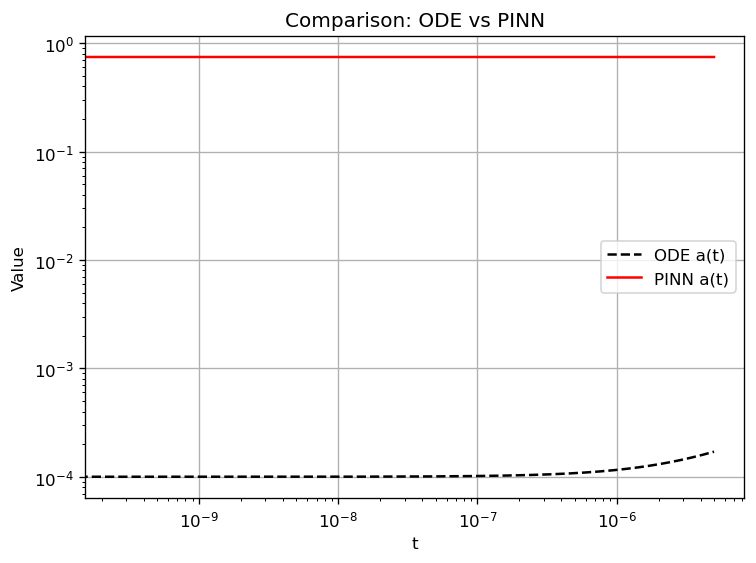

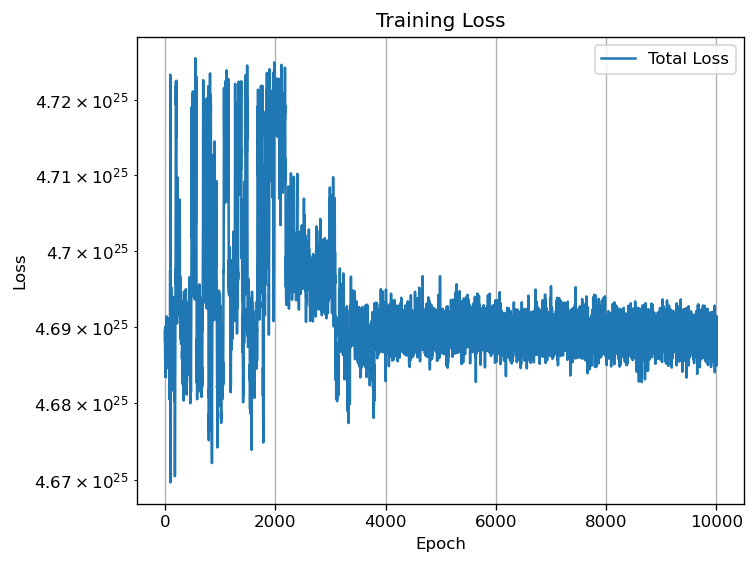

In [13]:
evaluate_and_plot(solver)

Evaluation time: 0.01 s


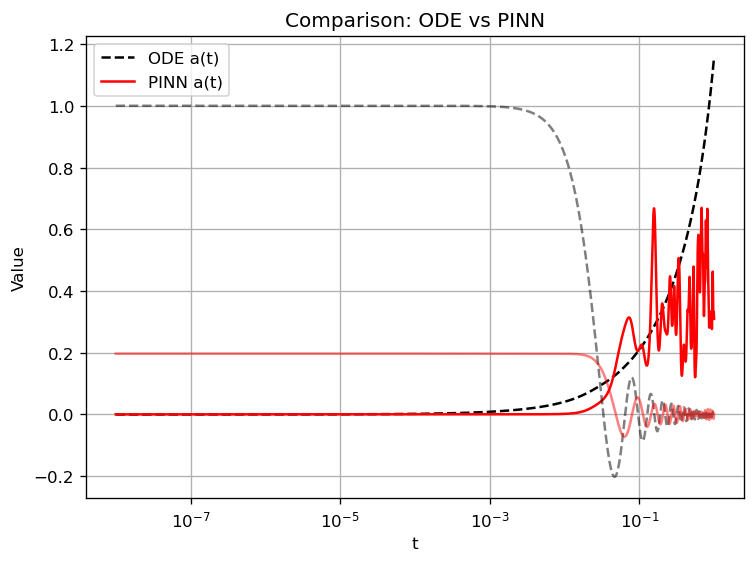

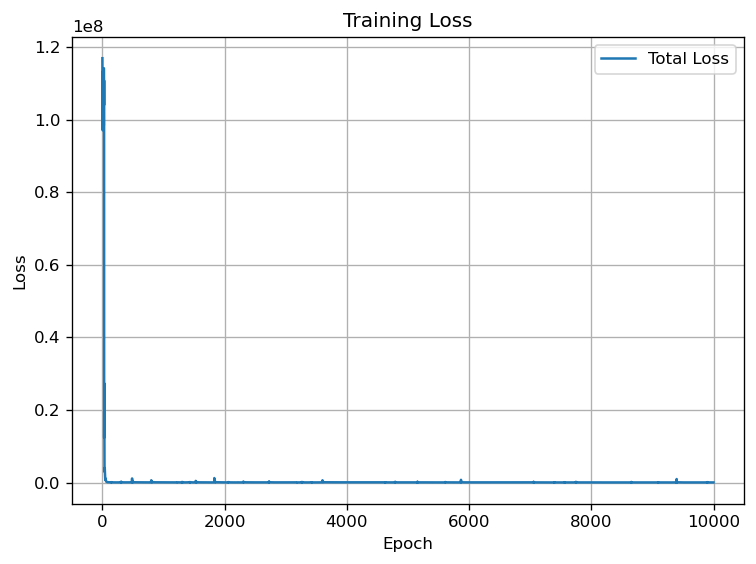

In [55]:
evaluate_and_plot(solver)

In [26]:
class FourierFeatures(nn.Module):
    def __init__(self, in_features=1, out_features=128, scale=10.0, device=None, dtype=torch.float32):
        super().__init__()
        B = torch.randn((out_features, in_features), device=device, dtype=dtype) * scale
        self.register_buffer('B', B)

    def forward(self, x):
        x_proj = 2 * np.pi * x @ self.B.T
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class ResidualBlock(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.fc1 = nn.Linear(width, width)
        self.fc2 = nn.Linear(width, width)
    
    def forward(self, x):
        identity = x
        x = torch.sin(self.fc1(x))
        x = self.fc2(x)
        return x + identity

class ScaleFactorNet(nn.Module):
    def __init__(self, hidden=64, depth=3):
        super().__init__()
        layers = []
        layers.append(nn.Linear(1, hidden))
        for _ in range(depth):
            layers.append(nn.Tanh())
            layers.append(nn.Linear(hidden, hidden))
        layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden, 1))
        self.net = nn.Sequential(*layers)
        self.softplus = nn.Softplus()

    def forward(self, t):
        a = self.net(t)
        return self.softplus(a).clamp(min=1e-8)

class PhiNet(nn.Module):
    def __init__(self, N_fields, embed_dim=64, hidden=64, blocks=3, fourier_scale=10.0):
        super().__init__()
        self.N_fields = N_fields
        self.fourier = FourierFeatures(1, embed_dim, scale=fourier_scale)
        layers = [nn.Linear(2 * embed_dim, hidden)]
        for _ in range(blocks):
            layers.append(ResidualBlock(hidden))
        self.net = nn.Sequential(*layers)
        self.output = nn.Linear(hidden, N_fields)

    def forward(self, t):
        x = self.fourier(t)
        x = self.net(x)
        return self.output(x)

class Modular_PINN(nn.Module):
    def __init__(self, N_fields, embed_dim=64, hidden=128, blocks=3, fourier_scale=10.0,
                 device=None, dtype=torch.float32):
        super().__init__()
        self.device = device
        self.dtype = dtype

        self.a_net = ScaleFactorNet(hidden=hidden//2).to(device, dtype)
        self.phi_net = PhiNet(N_fields, embed_dim, hidden, blocks, fourier_scale).to(device, dtype)

    def forward(self, t):
        a = self.a_net(t)
        phi = self.phi_net(t)
        return a, phi

    
# -------------------------
# PINN solver
# -------------------------
class PINNSolver:
    def __init__(self, N_fields=1, m_vec=[100],
                 rho_m0=0.81, rho_r0=0.00027138, rho_l0=2.19,
                 a0=1e-8, phi0=None, phi_dot0=None,
                 t_span=(0.0, 1.0), t_eval=None, folder_name='results',
                 device=None, dtype=torch.float32):

        self.device = device or (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
        self.dtype = dtype
        print("Using device:", self.device)

        self.N_fields = int(N_fields)
        self.m_vec = np.array(m_vec if m_vec is not None else [100.0] * self.N_fields, dtype=np.float32)
        self.rho_m0 = rho_m0
        self.rho_r0 = rho_r0
        self.rho_l0 = rho_l0

        self.a0 = float(a0)
        self.phi0 = np.array(phi0 if phi0 is not None else [1.0] * self.N_fields, dtype=np.float32)
        self.phi_dot0 = np.array(phi_dot0 if phi_dot0 is not None else [0.0] * self.N_fields, dtype=np.float32)
        self.y0 = np.concatenate([[self.a0], self.phi0, self.phi_dot0]).astype(np.float32)

        self.t_span = t_span
        if t_eval is None:
            self.t_eval = np.logspace(np.log10(self.a0), np.log10(float(self.t_span[1]) + 1e-12), 20000).astype(np.float32)
        else:
            self.t_eval = np.array(t_eval, dtype=np.float32)

        os.makedirs(folder_name, exist_ok=True)
        self.folder_name = folder_name

        # model
        self.model = Modular_PINN(self.N_fields, device=self.device, dtype=self.dtype).to(self.device, dtype=self.dtype)

        # torch constants
        self.m_vec_torch = torch.tensor(self.m_vec, dtype=self.dtype, device=self.device).reshape(1, -1)
        self.phi0_torch = torch.tensor(self.phi0.reshape(1, -1), dtype=self.dtype, device=self.device)
        self.a0_torch = torch.tensor([[self.a0]], dtype=self.dtype, device=self.device)
        self.t0_torch = torch.tensor([[0.0]], dtype=self.dtype, device=self.device)
        self.eps = torch.tensor(1e-12, dtype=self.dtype, device=self.device)

    # ---------- ODE reference ----------
    def ode_system(self, t, y):
        N = self.N_fields
        a = y[0]
        phi = y[1:N + 1]
        phi_dot = y[N + 1:2 * N + 1]
        kinetic = 0.5 * np.sum((phi_dot * a) ** 2)
        potential = 0.5 * np.sum((self.m_vec ** 2) * (phi * a) ** 2)
        H = np.sqrt((1.0 / 3.0) * (kinetic + potential + self.rho_m0 / a + self.rho_r0 / a ** 2 + self.rho_l0 * a ** 2))
        a_dot = H
        phi_ddot = - np.sqrt(3.0) * np.sqrt(
            0.5 * np.sum(phi_dot ** 2) +
            0.5 * np.sum((self.m_vec ** 2) * phi ** 2) +
            self.rho_m0 / a ** 3 + self.rho_r0 / a ** 4 + self.rho_l0
        ) * phi_dot - (self.m_vec ** 2) * phi

        dydt = np.zeros_like(y)
        dydt[0] = a_dot
        dydt[1:N + 1] = phi_dot
        dydt[N + 1:2 * N + 1] = phi_ddot
        return dydt

    def solve_ode(self):
        print("Solving ODE reference solution...")
        t0 = time.time()
        sol = solve_ivp(self.ode_system, self.t_span, self.y0, t_eval=self.t_eval, method='RK45', rtol=1e-6, atol=1e-9)
        print(f"ODE solve time: {time.time() - t0:.2f} s")
        self.a_sol = sol.y[0, :].astype(np.float32)
        self.phi_sol = sol.y[1:1 + self.N_fields, :].astype(np.float32)

    # ---------- Physics loss ----------
    def physics_loss(self, t_batch):
        a, phi = self.model(t_batch)
        a_t = torch.autograd.grad(a, t_batch, torch.ones_like(a), create_graph=True, allow_unused=True)[0]
        phi_t = torch.autograd.grad(phi, t_batch, torch.ones_like(phi), create_graph=True, allow_unused=True)[0]
        phi_tt = torch.autograd.grad(phi_t, t_batch, torch.ones_like(phi_t), create_graph=True, allow_unused=True)[0]

        # fallback for unused
        a_t = torch.zeros_like(a) if a_t is None else a_t
        phi_t = torch.zeros_like(phi) if phi_t is None else phi_t
        phi_tt = torch.zeros_like(phi) if phi_tt is None else phi_tt

        kinetic = 0.5 * torch.sum((phi_t ** 2) * (a ** 2), dim=1, keepdim=True)
        potential = 0.5 * torch.sum((self.m_vec_torch ** 2) * (phi ** 2) * (a ** 2), dim=1, keepdim=True)
        Friedmann = a_t - torch.sqrt((1.0 / 3.0) * (kinetic + potential + self.rho_m0 / a + self.rho_r0 / (a ** 2) + self.rho_l0 * (a ** 2)) + self.eps)
        sqsumrho = torch.sqrt(torch.tensor(3.0, device=self.device, dtype=self.dtype)) * torch.sqrt(
            0.5 * torch.sum(phi_t ** 2, dim=1, keepdim=True) +
            0.5 * torch.sum((self.m_vec_torch ** 2) * (phi ** 2), dim=1, keepdim=True) +
            self.rho_m0 / (a ** 3) + self.rho_r0 / (a ** 4) + self.rho_l0 + self.eps
        )
        KG = phi_tt + sqsumrho * phi_t + (self.m_vec_torch ** 2) * phi
        return torch.mean(Friedmann ** 2) + torch.mean(KG ** 2)

    def initial_loss(self):
        a_pred0, phi_pred0 = self.model(self.t0_torch)
        return 4.0 * torch.mean((a_pred0 - self.a0_torch) ** 2) + 30.0 * torch.mean((phi_pred0 - self.phi0_torch) ** 2)
#         return 4.0 * torch.mean((torch.log10(a_pred0) - torch.log10(self.a0_torch)) ** 2) + 30.0 * torch.mean((phi_pred0 - self.phi0_torch) ** 2)

    # ---------- Adam training ----------
    def train(self, max_epochs_adam=1200, physics_weight=10.0, ic_weight=300.0,
              N_f=2000, collocation_batch=512, print_every=200, lr=1e-5):
        optimizer = optim.Adam(self.model.parameters(), lr=lr)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.4)
        scaler = torch.cuda.amp.GradScaler(enabled=(self.device.type == 'cuda'))
        self.loss_history = []

        t_min = 0.0
        t_max = 1.0

        print("Training PINN (Adam)...")
        t_start = time.time()

        for epoch in range(max_epochs_adam):
            idx = np.random.randint(0, N_f, collocation_batch)
            t_f = torch.linspace(t_min, t_max, N_f, device=self.device, dtype=self.dtype).reshape(-1, 1)
            t_batch = t_f[idx].clone().requires_grad_()

            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=(self.device.type == 'cuda')):
                loss_physics_val = self.physics_loss(t_batch)
                loss_ic_val = self.initial_loss()
                loss = physics_weight * loss_physics_val + ic_weight * loss_ic_val

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            self.loss_history.append(loss.item())

            if epoch % print_every == 0 or epoch == max_epochs_adam - 1:
                percent = 100 * epoch / max_epochs_adam
                print(f"Epoch {epoch:5d}/{max_epochs_adam} ({percent:5.1f}%) | Total Loss: {loss.item():.3e}")

        print(f"Adam training finished in {time.time() - t_start:.2f} s")

    # ---------- LBFGS optimization ----------
    def optimize_lbfgs(self, physics_weight=10.0, ic_weight=300.0, N_f=1000):
        print("Starting LBFGS optimization...")
        optimizer_lbfgs = optim.LBFGS(
            self.model.parameters(),
            lr=1.0,
            max_iter=5000,
            tolerance_grad=1e-9,
            tolerance_change=1e-10,
            history_size=100,
            line_search_fn='strong_wolfe'
        )

        t0 = time.time()
        t_f = torch.linspace(0.0, 1.0, N_f, device=self.device, dtype=self.dtype).reshape(-1, 1).requires_grad_()

        def closure():
            optimizer_lbfgs.zero_grad()
            loss = physics_weight * self.physics_loss(t_f) + ic_weight * self.initial_loss()
            loss.backward()
            return loss

        optimizer_lbfgs.step(closure)
        print(f"LBFGS optimization time: {time.time() - t0:.2f} s")

# -------------------------
# Evaluation & plotting
# -------------------------
def evaluate_and_plot(solver):
    t0 = time.time()
    # Prepare collocation points
    t_plot = torch.tensor(solver.t_eval, device=solver.device, dtype=solver.dtype).reshape(-1, 1).requires_grad_(True)
    a_pred, phi_pred = solver.model(t_plot)
    solver.a_pred = a_pred.detach().cpu().numpy().flatten()
    solver.phi_pred = phi_pred.detach().cpu().numpy().T
    print(f"Evaluation time: {time.time() - t0:.2f} s")

    # ---------- Plot ODE vs PINN ----------
    plt.figure(dpi=120)
    plt.plot(solver.t_eval, solver.a_sol, 'k--', label='ODE a(t)')
    plt.plot(solver.t_eval, solver.a_pred, 'r-', label='PINN a(t)')
    for i in range(min(solver.N_fields, 5)):
        plt.plot(solver.t_eval, solver.phi_sol[i, :], 'k--', alpha=0.5)
        plt.plot(solver.t_eval, solver.phi_pred[i, :], 'r-', alpha=0.5)
    plt.xscale('log')
#     plt.yscale('log')
    plt.xlabel('t')
#     plt.xlim(0.5,1)
#     plt.ylim(-0.1,0.1)
    plt.ylabel('Value')
    plt.title('Comparison: ODE vs PINN')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(solver.folder_name, 'comparison.png'))
    plt.show()

    # ---------- Plot loss curves ----------
    if hasattr(solver, 'loss_history') and solver.loss_history:
        plt.figure(dpi=120)
        plt.plot(solver.loss_history, label='Total Loss')
        plt.yscale('log')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(solver.folder_name, 'loss_curves.png'))
        plt.show()

In [27]:
if __name__ == "__main__":
    solver = PINNSolver(N_fields=1,m_vec=[70])  # example with 2 fields

    t_start_total = time.time()

    # ODE solve
    t0 = time.time()
    solver.solve_ode()
    print(f"Time for ODE solve: {time.time() - t0:.2f} s")

    # Adam training
    t0 = time.time()
    solver.train(max_epochs_adam=20000, collocation_batch=512)
    print(f"Time for Adam training: {time.time() - t0:.2f} s")

    # LBFGS optimization
    t0 = time.time()
    print(f"Time for LBFGS: __________")
    solver.optimize_lbfgs(N_f=400)
    print(f"Time for LBFGS: {time.time() - t0:.2f} s")

    # Evaluation
    t0 = time.time()
    t_plot = torch.tensor(solver.t_eval, device=solver.device, dtype=solver.dtype).reshape(-1, 1).requires_grad_(True)
    solver.a_pred, solver.phi_pred = solver.model(t_plot)
    solver.a_pred = solver.a_pred.detach().cpu().numpy().flatten()
    solver.phi_pred = solver.phi_pred.detach().cpu().numpy().T
    print(f"Time for evaluation: {time.time() - t0:.2f} s")

    print(f"Total pipeline time: {time.time() - t_start_total:.2f} s")


Using device: cuda
Solving ODE reference solution...
ODE solve time: 0.12 s
Time for ODE solve: 0.12 s
Training PINN (Adam)...
Epoch     0/20000 (  0.0%) | Total Loss: 1.915e+07


/tmp/ipykernel_22041/1279340848.py:179: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(self.device.type == 'cuda'))
/tmp/ipykernel_22041/1279340848.py:194: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(self.device.type == 'cuda')):


Epoch   200/20000 (  1.0%) | Total Loss: 5.174e+05
Epoch   400/20000 (  2.0%) | Total Loss: 9.143e+04
Epoch   600/20000 (  3.0%) | Total Loss: 3.879e+04
Epoch   800/20000 (  4.0%) | Total Loss: 2.534e+04
Epoch  1000/20000 (  5.0%) | Total Loss: 1.824e+04
Epoch  1200/20000 (  6.0%) | Total Loss: 1.553e+04
Epoch  1400/20000 (  7.0%) | Total Loss: 1.276e+04
Epoch  1600/20000 (  8.0%) | Total Loss: 1.130e+04
Epoch  1800/20000 (  9.0%) | Total Loss: 1.052e+04
Epoch  2000/20000 ( 10.0%) | Total Loss: 9.237e+03
Epoch  2200/20000 ( 11.0%) | Total Loss: 9.086e+03
Epoch  2400/20000 ( 12.0%) | Total Loss: 8.719e+03
Epoch  2600/20000 ( 13.0%) | Total Loss: 8.222e+03
Epoch  2800/20000 ( 14.0%) | Total Loss: 8.145e+03
Epoch  3000/20000 ( 15.0%) | Total Loss: 7.924e+03
Epoch  3200/20000 ( 16.0%) | Total Loss: 7.732e+03
Epoch  3400/20000 ( 17.0%) | Total Loss: 7.468e+03
Epoch  3600/20000 ( 18.0%) | Total Loss: 7.367e+03
Epoch  3800/20000 ( 19.0%) | Total Loss: 7.216e+03
Epoch  4000/20000 ( 20.0%) | To

Evaluation time: 0.00 s


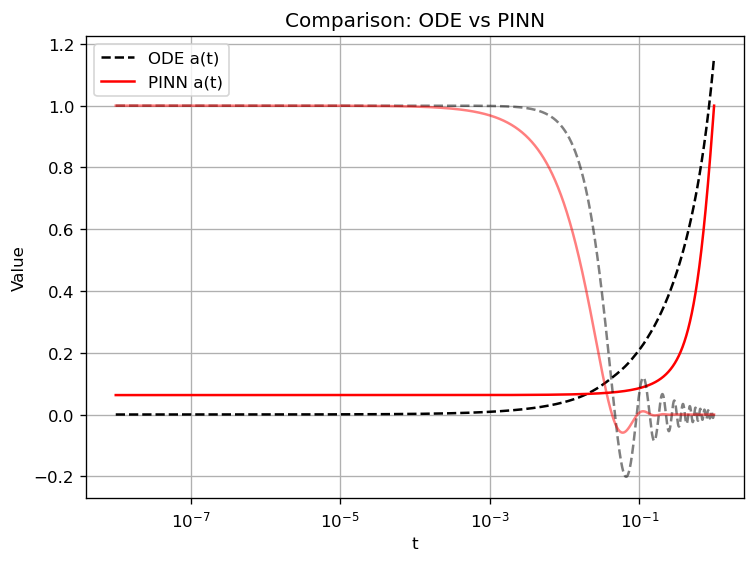

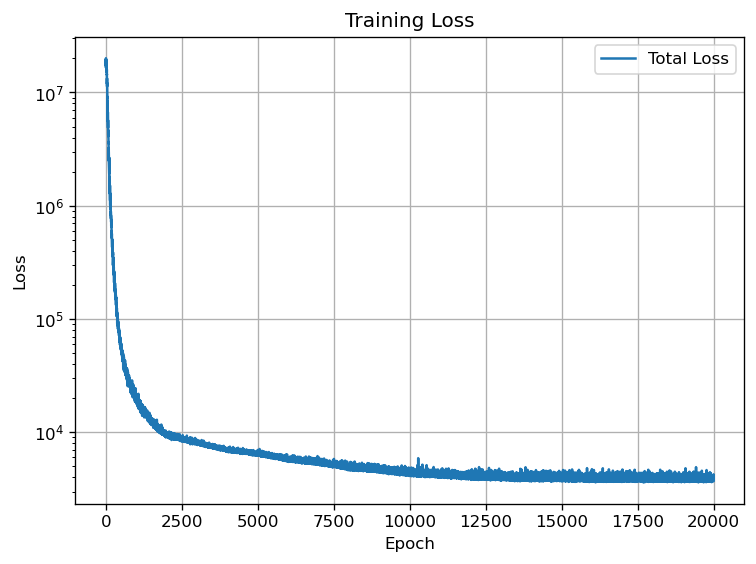

In [28]:
evaluate_and_plot(solver)

### Time scale

In [4]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -------------------------
# Model components
# -------------------------
class FourierFeatures(nn.Module):
    def __init__(self, in_features=1, out_features=64, scale=10.0, device=None, dtype=torch.float32):
        super().__init__()
        B = torch.randn((out_features, in_features), device=device, dtype=dtype) * scale
        self.register_buffer('B', B)
        self.register_buffer('two_pi', torch.tensor(2.0 * np.pi, device=device, dtype=dtype))

    def forward(self, x):
        x_proj = self.two_pi * (x @ self.B.T)
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)


class ResidualBlock(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.fc1 = nn.Linear(width, width)
        self.fc2 = nn.Linear(width, width)

    def forward(self, x):
        return x + self.fc2(torch.sin(self.fc1(x)))


class F_PINN(nn.Module):
    def __init__(self, N_fields, embed_dim=64, hidden=128, blocks=3, fourier_scale=10.0, device=None, dtype=torch.float32):
        super().__init__()
        self.N_fields = N_fields
        self.fourier = FourierFeatures(1, embed_dim, scale=fourier_scale, device=device, dtype=dtype)
        layers = [nn.Linear(2 * embed_dim, hidden)]
        for _ in range(blocks):
            layers.append(ResidualBlock(hidden))
        self.net = nn.Sequential(*layers)
        self.output = nn.Linear(hidden, 1 + N_fields)
        self.softplus = nn.Softplus()

    def forward(self, t):
        x = self.fourier(t)
        x = self.net(x)
        x = self.output(x)
        a = self.softplus(x[:, 0:1]).clamp(min=1e-6)
        phi = x[:, 1:]
        return a, phi

# -------------------------
# PINN solver
# -------------------------
class PINNSolver:
    def __init__(self, N_fields=1, m_vec=[200],
                 rho_m0=0.81, rho_r0=0.00027138, rho_l0=2.19,
                 a0=1e-8, phi0=None, phi_dot0=None,
                 t_span=(0.0, 1.0), t_eval=None, folder_name='results',
                 device=None, dtype=torch.float32):

        self.device = device or (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
        self.dtype = dtype
        print("Using device:", self.device)

        self.N_fields = int(N_fields)
        self.m_vec = np.array(m_vec if m_vec is not None else [10.0] * self.N_fields, dtype=np.float32)
        self.rho_m0 = rho_m0
        self.rho_r0 = rho_r0
        self.rho_l0 = rho_l0

        self.a0 = float(a0)
        self.phi0 = np.array(phi0 if phi0 is not None else [1.0] * self.N_fields, dtype=np.float32)
        self.phi_dot0 = np.array(phi_dot0 if phi_dot0 is not None else [0.0] * self.N_fields, dtype=np.float32)
        self.y0 = np.concatenate([[self.a0], self.phi0, self.phi_dot0]).astype(np.float32)

        self.t_span = t_span
        if t_eval is None:
            self.t_eval = np.logspace(np.log10(self.a0), np.log10(float(self.t_span[1]) + 1e-12), 2000).astype(np.float32)
        else:
            self.t_eval = np.array(t_eval, dtype=np.float32)

        os.makedirs(folder_name, exist_ok=True)
        self.folder_name = folder_name

        # model
        self.model = F_PINN(self.N_fields, device=self.device, dtype=self.dtype).to(self.device, dtype=self.dtype)

        # torch constants
        self.m_vec_torch = torch.tensor(self.m_vec, dtype=self.dtype, device=self.device).reshape(1, -1)
        self.phi0_torch = torch.tensor(self.phi0.reshape(1, -1), dtype=self.dtype, device=self.device)
        self.a0_torch = torch.tensor([[self.a0]], dtype=self.dtype, device=self.device)
        self.t0_torch = torch.tensor([[0.0]], dtype=self.dtype, device=self.device)
        self.eps = torch.tensor(1e-12, dtype=self.dtype, device=self.device)
        
        # Time scale, default (no scaling = 1)
        self.time_scale = 1.0

    # ---------- ODE reference ----------
    def ode_system(self, t, y):
        N = self.N_fields
        a = y[0]
        phi = y[1:N + 1]
        phi_dot = y[N + 1:2 * N + 1]
        kinetic = 0.5 * np.sum((phi_dot * a) ** 2)
        potential = 0.5 * np.sum((self.m_vec ** 2) * (phi * a) ** 2)
        H = np.sqrt((1.0 / 3.0) * (kinetic + potential + self.rho_m0 / a + self.rho_r0 / a ** 2 + self.rho_l0 * a ** 2))
        a_dot = H
        phi_ddot = - np.sqrt(3.0) * np.sqrt(
            0.5 * np.sum(phi_dot ** 2) +
            0.5 * np.sum((self.m_vec ** 2) * phi ** 2) +
            self.rho_m0 / a ** 3 + self.rho_r0 / a ** 4 + self.rho_l0
        ) * phi_dot - (self.m_vec ** 2) * phi

        dydt = np.zeros_like(y)
        dydt[0] = a_dot
        dydt[1:N + 1] = phi_dot
        dydt[N + 1:2 * N + 1] = phi_ddot
        return dydt

    def solve_ode(self):
        print("Solving ODE reference solution...")
        t0 = time.time()
        sol = solve_ivp(self.ode_system, self.t_span, self.y0, t_eval=self.t_eval, method='RK45', rtol=1e-6, atol=1e-9)
        print(f"ODE solve time: {time.time() - t0:.2f} s")
        self.a_sol = sol.y[0, :].astype(np.float32)
        self.phi_sol = sol.y[1:1 + self.N_fields, :].astype(np.float32)

    # ---------- Physics loss ----------
    def physics_loss(self, t_batch):
        
        #t_s = S * t
        S = float(self.time_scale)
        t_scaled = (t_batch * S).requires_grad_()
        
        a_scaled, phi_scaled = self.model(t_scaled)   # model expects scaled time
        
        #phidot(t) = S*phidot(t_s), phidott(t) = S^2*phidot(t_s)
        # compute derivatives wrt scaled time
        a_t_tilde = torch.autograd.grad(a_scaled, t_scaled, torch.ones_like(a_scaled), create_graph=True, allow_unused=True)[0]
        phi_t_tilde = torch.autograd.grad(phi_scaled, t_scaled, torch.ones_like(phi_scaled), create_graph=True, allow_unused=True)[0]
        phi_tt_tilde = torch.autograd.grad(phi_t_tilde, t_scaled, torch.ones_like(phi_t_tilde), create_graph=True, allow_unused=True)[0]

        # handle possible None (safe fallback)
        if a_t_tilde is None:
            a_t_tilde = torch.zeros_like(a_scaled)
        if phi_t_tilde is None:
            phi_t_tilde = torch.zeros_like(phi_scaled)
        if phi_tt_tilde is None:
            phi_tt_tilde = torch.zeros_like(phi_scaled)

        # Chain rule to get derivatives w.r.t physical time t:
        a_t = a_t_tilde * S
        phi_t = phi_t_tilde * S
        phi_tt = phi_tt_tilde * (S**2)

        kinetic = 0.5 * torch.sum((phi_t ** 2) * (a_scaled ** 2), dim=1, keepdim=True)
        potential = 0.5 * torch.sum((self.m_vec_torch ** 2) * (phi_scaled ** 2) * (a_scaled ** 2), dim=1, keepdim=True)

        Friedmann = a_t - torch.sqrt((1.0 / 3.0) * (kinetic + potential + self.rho_m0 / a_scaled + self.rho_r0 / (a_scaled ** 2) + self.rho_l0 * (a_scaled ** 2)) + self.eps)

        sqsumrho = torch.sqrt(torch.tensor(3.0, device=self.device, dtype=self.dtype)) * torch.sqrt(
            0.5 * torch.sum(phi_t ** 2, dim=1, keepdim=True) +
            0.5 * torch.sum((self.m_vec_torch ** 2) * (phi_scaled ** 2), dim=1, keepdim=True) +
            self.rho_m0 / (a_scaled ** 3) + self.rho_r0 / (a_scaled ** 4) + self.rho_l0 + self.eps
        )

        KG = phi_tt + sqsumrho * phi_t + (self.m_vec_torch ** 2) * phi_scaled
        return torch.mean(Friedmann ** 2) + torch.mean(KG ** 2)

    def initial_loss(self):
        a_pred0, phi_pred0 = self.model(self.t0_torch)
        return 4.0 * torch.mean((a_pred0 - self.a0_torch) ** 2) + 30.0 * torch.mean((phi_pred0 - self.phi0_torch) ** 2)
#         return 4.0 * torch.mean((torch.log10(a_pred0) - torch.log10(self.a0_torch)) ** 2) + 30.0 * torch.mean((phi_pred0 - self.phi0_torch) ** 2)

    # ---------- Adam training ----------
    def train(self, max_epochs_adam=1200, physics_weight=10.0, ic_weight=300.0,
              N_f=2000, collocation_batch=512, print_every=200, lr=1e-3):
        optimizer = optim.Adam(self.model.parameters(), lr=lr)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.4)
        scaler = torch.cuda.amp.GradScaler(enabled=(self.device.type == 'cuda'))
        self.loss_history = []

        t_min = 0.0
        t_max = 1.0

        print("Training PINN (Adam)...")
        t_start = time.time()

        for epoch in range(max_epochs_adam):
            idx = np.random.randint(0, N_f, collocation_batch)
            t_f = torch.linspace(t_min, t_max, N_f, device=self.device, dtype=self.dtype).reshape(-1, 1)
            t_batch = t_f[idx].clone().requires_grad_()

            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=(self.device.type == 'cuda')):
                loss_physics_val = self.physics_loss(t_batch)
                loss_ic_val = self.initial_loss()
                loss = physics_weight * loss_physics_val + ic_weight * loss_ic_val

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            self.loss_history.append(loss.item())

            if epoch % print_every == 0 or epoch == max_epochs_adam - 1:
                percent = 100 * epoch / max_epochs_adam
                print(f"Epoch {epoch:5d}/{max_epochs_adam} ({percent:5.1f}%) | Total Loss: {loss.item():.3e}")

        print(f"Adam training finished in {time.time() - t_start:.2f} s")

    # ---------- LBFGS optimization ----------
    def optimize_lbfgs(self, physics_weight=10.0, ic_weight=300.0, N_f=1000):
        print("Starting LBFGS optimization...")
        optimizer_lbfgs = optim.LBFGS(
            self.model.parameters(),
            lr=1.0,
            max_iter=5000,
            tolerance_grad=1e-9,
            tolerance_change=1e-10,
            history_size=100,
            line_search_fn='strong_wolfe'
        )

        t0 = time.time()
        t_f = torch.linspace(0.0, 1.0, N_f, device=self.device, dtype=self.dtype).reshape(-1, 1).requires_grad_()

        def closure():
            optimizer_lbfgs.zero_grad()
            loss = physics_weight * self.physics_loss(t_f) + ic_weight * self.initial_loss()
            loss.backward()
            return loss

        optimizer_lbfgs.step(closure)
        print(f"LBFGS optimization time: {time.time() - t0:.2f} s")

# -------------------------
# Evaluation & plotting
# -------------------------
def evaluate_and_plot(solver):
    t0 = time.time()
    # Prepare collocation points
    t_plot = torch.tensor(solver.t_eval, device=solver.device, dtype=solver.dtype).reshape(-1, 1).requires_grad_(True)
#     t_plot = torch.tensor(self.t_eval, device=self.device, dtype=self.dtype).reshape(-1,1)
    t_scaled = (t_plot * float(solver.time_scale)).requires_grad_(True)
    a_scaled, phi_scaled = solver.model(t_scaled)
    print(a_scaled,phi_scaled)

    # a_scaled and phi_scaled are actually functions of scaled time but represent physical a(t),phi(t)
    solver.a_pred = a_scaled.detach().cpu().numpy().flatten()
    solver.phi_pred = phi_scaled.detach().cpu().numpy().T
    print(f"Evaluation time: {time.time() - t0:.2f} s")

    # ---------- Plot ODE vs PINN ----------
    plt.figure(dpi=120)
    plt.plot(solver.t_eval, solver.a_sol, 'k--', label='ODE a(t)')
    plt.plot(solver.t_eval, solver.a_pred, 'r-', label='PINN a(t)')
    for i in range(min(solver.N_fields, 5)):
        plt.plot(solver.t_eval, solver.phi_sol[i, :], '--', alpha=0.5, label='ODE phi(t)')
        plt.plot(solver.t_eval, solver.phi_pred[i, :], '-', alpha=0.5, label='PINN phi(t)')
    plt.xscale('log')
#     plt.yscale('log')
    plt.xlabel('t')
#     plt.xlim(0.5,1)
#     plt.ylim(-0.1,0.1)
    plt.ylabel('Value')
    plt.title('Comparison: ODE vs PINN')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(solver.folder_name, 'comparison.png'))
    plt.show()

    # ---------- Plot loss curves ----------
    if hasattr(solver, 'loss_history') and solver.loss_history:
        plt.figure(dpi=120)
        plt.plot(solver.loss_history, label='Total Loss')
        plt.yscale('log')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(solver.folder_name, 'loss_curves.png'))
        plt.show()

In [7]:
if __name__ == "__main__":
    solver = PINNSolver(N_fields=1,m_vec=[60])  # example with 2 fields
    solver.time_scale = 2# 2e-4
    t_start_total = time.time()

    # ODE solve
    t0 = time.time()
    solver.solve_ode()
    print(f"Time for ODE solve: {time.time() - t0:.2f} s")

    # Adam training
    t0 = time.time()
    solver.train(max_epochs_adam=10000, collocation_batch=512)
    print(f"Time for Adam training: {time.time() - t0:.2f} s")

    # LBFGS optimization
    t0 = time.time()
    print(f"Time for LBFGS: __________")
    solver.optimize_lbfgs(N_f=1000)
    print(f"Time for LBFGS: {time.time() - t0:.2f} s")

    # Evaluation
    t0 = time.time()
    t_plot = torch.tensor(solver.t_eval, device=solver.device, dtype=solver.dtype).reshape(-1, 1).requires_grad_(True)
    solver.a_pred, solver.phi_pred = solver.model(t_plot)
    solver.a_pred = solver.a_pred.detach().cpu().numpy().flatten()
    solver.phi_pred = solver.phi_pred.detach().cpu().numpy().T
    print(f"Time for evaluation: {time.time() - t0:.2f} s")

    print(f"Total pipeline time: {time.time() - t_start_total:.2f} s")


Using device: cuda
Solving ODE reference solution...
ODE solve time: 0.10 s
Time for ODE solve: 0.10 s
Training PINN (Adam)...
Epoch     0/10000 (  0.0%) | Total Loss: 7.168e+08


/tmp/ipykernel_7574/554591357.py:185: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(self.device.type == 'cuda'))
/tmp/ipykernel_7574/554591357.py:200: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(self.device.type == 'cuda')):


Epoch   200/10000 (  2.0%) | Total Loss: 3.683e+04
Epoch   400/10000 (  4.0%) | Total Loss: 1.955e+04
Epoch   600/10000 (  6.0%) | Total Loss: 1.720e+04
Epoch   800/10000 (  8.0%) | Total Loss: 2.125e+04
Epoch  1000/10000 ( 10.0%) | Total Loss: 1.348e+04
Epoch  1200/10000 ( 12.0%) | Total Loss: 8.752e+04
Epoch  1400/10000 ( 14.0%) | Total Loss: 4.281e+04
Epoch  1600/10000 ( 16.0%) | Total Loss: 1.498e+05
Epoch  1800/10000 ( 18.0%) | Total Loss: 1.597e+04
Epoch  2000/10000 ( 20.0%) | Total Loss: 4.497e+04
Epoch  2200/10000 ( 22.0%) | Total Loss: 9.617e+03
Epoch  2400/10000 ( 24.0%) | Total Loss: 9.824e+03
Epoch  2600/10000 ( 26.0%) | Total Loss: 9.572e+03
Epoch  2800/10000 ( 28.0%) | Total Loss: 9.364e+03
Epoch  3000/10000 ( 30.0%) | Total Loss: 9.612e+03
Epoch  3200/10000 ( 32.0%) | Total Loss: 9.895e+03
Epoch  3400/10000 ( 34.0%) | Total Loss: 1.565e+04
Epoch  3600/10000 ( 36.0%) | Total Loss: 1.031e+04
Epoch  3800/10000 ( 38.0%) | Total Loss: 2.157e+04
Epoch  4000/10000 ( 40.0%) | To

tensor([[0.0723],
        [0.0723],
        [0.0723],
        ...,
        [0.3146],
        [0.3104],
        [0.3018]], device='cuda:0', grad_fn=<ClampBackward1>) tensor([[9.9840e-01],
        [9.9840e-01],
        [9.9840e-01],
        ...,
        [1.2365e-04],
        [1.0030e-04],
        [5.6293e-05]], device='cuda:0', grad_fn=<SliceBackward0>)
Evaluation time: 0.00 s


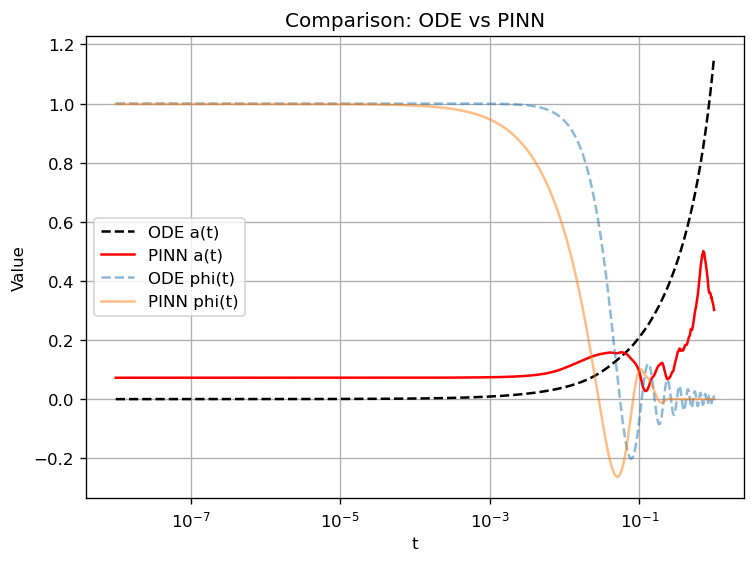

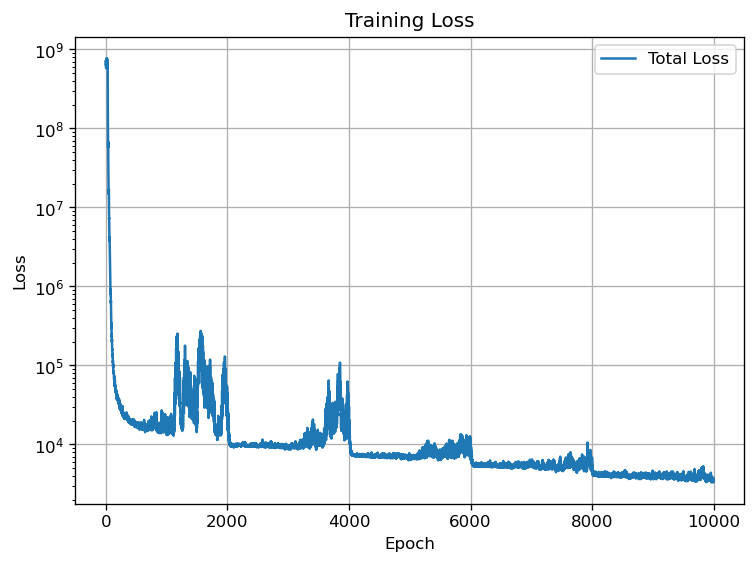

In [8]:
evaluate_and_plot(solver)

In [2]:
def check_units_reality(rho_m0, rho_r0, ma0):
    # ค่าคงที่ทางฟิสิกส์ (Physical Constants)
    h = 0.67 # Hubble parameter scale (H0 = 100h km/s/Mpc)
    H0_eV = 1.44e-33 * h # H0 in eV
    H0_inv_years = 9.778e9 / h # 1/H0 in years (approx Age of Universe)
    
    print("--- REALITY CHECK (Unit Consistency) ---")
    
    # 1. เช็คสัดส่วน Matter-Radiation (Equality Redshift)
    # สูตร: 1+z_eq = Omega_m / Omega_r
    if rho_r0 > 0:
        z_eq_code = (rho_m0 / rho_r0) - 1
        print(f"[Check 1] Matter-Radiation Equality (z_eq):")
        print(f"   Code Value:   z ~ {z_eq_code:.0f}")
        print(f"   Real World:   z ~ 3400")
        if 2500 < z_eq_code < 4000:
            print("   >>> STATUS: PASS (Consistent with Standard Cosmology)")
        else:
            print("   >>> STATUS: WARNING (Ratios might be non-standard)")
    else:
        print("[Check 1] rho_r0 is 0, cannot check Equality.")

    # 2. เช็คมวล Axion (Physical Mass)
    # สูตร: m_phys = m_code * H0
    m_phys_eV = ma0 * H0_eV
    print(f"\n[Check 2] Axion Mass:")
    print(f"   Code Input (m/H0): {ma0}")
    print(f"   Physical Mass:     {m_phys_eV:.2e} eV")
    
    # คำแนะนำตามช่วงมวล
    if m_phys_eV < 1e-30:
        print("   >>> Context: Extremely Ultralight (Dark Energy-like scale)")
    elif 1e-30 <= m_phys_eV <= 1e-18:
        print("   >>> Context: Fuzzy Dark Matter / ULA scale")
    else:
        print("   >>> Context: QCD Axion or Heavy Axion scale")
        
    # 3. เช็คเวลา (Time Scale)
    print(f"\n[Check 3] Time Unit:")
    print(f"   Code t=1.0 corresponds to: ~{H0_inv_years/1e9:.2f} Billion Years")

# --- วิธีใช้ ---
# เรียกใช้ฟังก์ชันนี้ก่อนรัน Simulation โดยใส่ค่าที่คุณตั้งไว้
# ตัวอย่าง:
check_units_reality(rho_m0=0.81, rho_r0=0.00027138, ma0=100)

--- REALITY CHECK (Unit Consistency) ---
[Check 1] Matter-Radiation Equality (z_eq):
   Code Value:   z ~ 2984
   Real World:   z ~ 3400
   >>> STATUS: PASS (Consistent with Standard Cosmology)

[Check 2] Axion Mass:
   Code Input (m/H0): 100
   Physical Mass:     9.65e-32 eV
   >>> Context: Extremely Ultralight (Dark Energy-like scale)

[Check 3] Time Unit:
   Code t=1.0 corresponds to: ~14.59 Billion Years


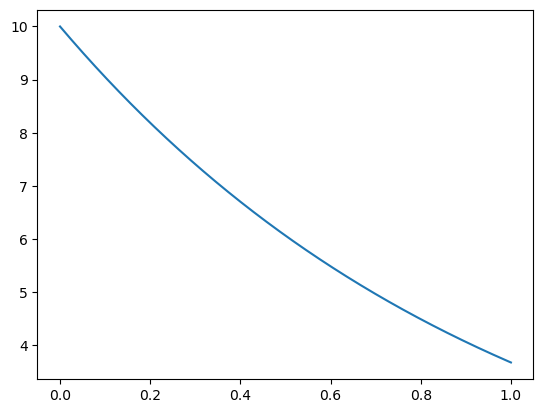

In [18]:
t = np.linspace(0,1,1000)
m = 10
x = np.cos(m*t)
y = 10*np.exp(-t)
plt.plot(t,y)